# Trustworthy Anomaly Agent on ESA-ADB: an end-to-end walkthrough

This notebook runs the **complete pipeline** of the project on real satellite telemetry
(ESA's Mission2, lightweight subset). It detects anomalies, calibrates how much you can
trust each detection, explains which channels caused it, and generates an operator alert
whose text is audited by an LLM judge before it reaches you. Along the way it explains
the **key design decisions** of each module: not just what runs, but *why it is built
this way*. For the project context (the operator's problem, the dataset, the
trustworthiness gap) see the [README](../README.md).

```
Telemetry (Mission2, channels 18-28)
  → [1] Detection      Windowed Isolation Forest         → anomaly score per window
  → [2] Uncertainty    conformal prediction              → calibrated confidence
  → [3] Attribution    channel-level explanation         → which sensors caused it
  → [4] Alert layer    grounded LLM brief + judge        → auditable operator alert
  → [5] This notebook  the whole chain, live
```

**How to use this notebook.** Reading it on GitHub takes about 15-20 minutes and
requires nothing: every output is committed. Running it yourself requires downloading
the dataset once (3.8 GB, instructions below). After the one-time preprocessing
(about 30 minutes) every later run skips the heavy steps automatically.

---
**Data attribution.** ESA Anomaly Dataset (ESA-ADB), © European Space Agency (ESOC),
KP Labs and Airbus Defence and Space, licensed
[CC BY 3.0 IGO](https://creativecommons.org/licenses/by/3.0/igo/).
Dataset: [10.5281/zenodo.12528696](https://doi.org/10.5281/zenodo.12528696) ·
Paper: [arXiv:2406.17826](https://arxiv.org/abs/2406.17826) ·
Code: [kplabs-pl/ESA-ADB](https://github.com/kplabs-pl/ESA-ADB) (MIT), minimally
vendored under `src/` (see `NOTICE`). All results below are traceable to the dataset.
No invented data.


## 0 · Setup & data

The pipeline needs the raw Mission2 telemetry **once**. If you only want to read this
notebook, skip ahead: every cell below is already executed.

1. Download the **ESA-Mission2** folder (3.8 GB) from Zenodo:
   [doi.org/10.5281/zenodo.12528696](https://doi.org/10.5281/zenodo.12528696)
2. Place it at `data/ESA-Mission2/` (so that `data/ESA-Mission2/labels.csv` exists).
3. Run the cells below. The first run preprocesses the raw channels into the
   train/test CSVs (about 30 minutes, one time). Later runs detect the existing
   output and skip the step.

Everything is deterministic: same input, same bytes out, down to the final
F0.5 = 0.9487. There is no hidden state and no cached shortcut in the pipeline itself.


In [62]:
import sys, time, subprocess
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))  # notebook lives in notebooks/
import config

TIMINGS: dict = {}  # wall-clock per heavy step, summarized at the end

RAW_DIR = config.REPO / "data" / "ESA-Mission2"
preprocessed = config.TEST_CSV.exists() and config.TRAIN_CSV.exists()

if preprocessed:
    print(f"[ok] Preprocessed CSVs found — ready.\n     {config.TEST_CSV.name}, {config.TRAIN_CSV.name}")
elif RAW_DIR.exists():
    print("[ok] Raw dataset found — the next cell will preprocess it (~30 min, one-time).")
else:
    raise SystemExit(
        "Dataset not found.\n"
        f"  Expected raw data at:        {RAW_DIR}\n"
        f"  (or preprocessed CSVs at:    {config.PREP_DIR})\n"
        "  Download ESA-Mission2 (~3.8 GB): https://doi.org/10.5281/zenodo.12528696\n"
        "  Then re-run this cell. See section '0 · Setup & data' above."
    )


[ok] Preprocessed CSVs found — ready.
     21_months.test.csv, 21_months.train.csv


In [63]:
# [1a] Raw telemetry -> canonical train/test CSVs (ESA's own prep, vendored — see NOTICE).
# Deterministic: depends ONLY on the immutable Zenodo raw data + preprocessing.py.
# To force regeneration (e.g. after editing the script): delete data/preprocessed_subset/.
if preprocessed:
    print("[skip] Already preprocessed — ~30 min saved.")
else:
    print("[run ] Preprocessing channels 18-28 (~30 min on Apple Silicon)...")
    t0 = time.perf_counter()
    subprocess.run(
        [sys.executable, str(config.REPO / "src" / "m1_detection" / "preprocessing.py"), str(RAW_DIR)],
        check=True,
    )
    TIMINGS["preprocess"] = time.perf_counter() - t0
    print(f"[done] Preprocessing finished in {TIMINGS['preprocess']/60:.1f} min.")


[skip] Already preprocessed — ~30 min saved.


## 1 · Detection: Windowed Isolation Forest

**What runs here.** ESA's own winning detector for this benchmark subset
(`subsequence_if`), executed **verbatim** from the vendored copy in
`src/m1_detection/vendor/algorithm.py`. We *reproduce* the paper's headline number.
Reproduce means: re-run ESA's published experiment with their own code, data and
metric, and land on their number (they report **F0.5 = 0.949**). That number then
doubles as a regression alarm: if any later change moves it, something broke.

**Why a simple forest and not deep learning?** The ESA-ADB paper's own finding: on the
*full* benchmark, every tested detector collapses (F0.5 ≈ 0.07). Nobody, not even the
authors, can tell in advance which detector to trust on which data (the *No Free Lunch*
problem). That is exactly why this project's contribution is the **trust layer**
(modules 2 to 4) rather than yet another detector: an operator facing a bare 0/1 flag
has no way to know when to believe it.


**Step A: train ESA's detector and score the test set.** A sliding window of 17
samples (about 5 minutes of telemetry at 18 s per sample) slides over the 11 channels.
Each window is flattened into one 187-dimensional point. An **Isolation Forest**
(Liu 2008) then tries to isolate each point with random cuts: the fewer cuts needed,
the more anomalous the window. This is the core of ESA's `algorithm.py` (quoted, not
re-implemented):

```python
# src/m1_detection/vendor/algorithm.py (condensed): the entire detection logic
data = sliding_window_view(data, window_shape=17, axis=0).reshape(-1, 17 * n_channels)
clf = IForest(n_estimators=200, random_state=42, ...)
clf.fit(data)                       # train: learn what "normal" looks like
result = clf.predict(data)          # execute: 0/1 per window
result = np.pad(result, 17 // 2)    # window center -> per-point flag
```


In [64]:
from m1_detection import model as m1_model

MODEL_PKL = config.CACHE_DIR / "model.pkl"
SCORES_TEST = config.CACHE_DIR / "scores_test.csv"

if MODEL_PKL.exists() and SCORES_TEST.exists():
    print("[skip] Trained model + test scores found — ~11 min saved.")
    print("       Deterministic (seed=42): retraining reproduces them byte-identically.")
    print("       To force it: delete both files from data/cached/ and re-run.")
else:
    print("[run ] Training Windowed iForest (21 months) + scoring the test set (~11 min)...")
    t0 = time.perf_counter()
    m1_model.main()
    TIMINGS["train+score"] = time.perf_counter() - t0
    print(f"[done] {TIMINGS['train+score']/60:.1f} min.")


[skip] Trained model + test scores found — ~11 min saved.
       Deterministic (seed=42): retraining reproduces them byte-identically.
       To force it: delete both files from data/cached/ and re-run.


**Step B: the official exam.** ESA's event-wise F0.5 metric (`ESAScores`, vendored),
computed exactly as the paper does. The `assert` makes this cell a tripwire: any
future change that breaks the reproduction fails loudly here.


In [65]:
import io, contextlib
from m1_detection import evaluation as m1_eval

with contextlib.redirect_stdout(io.StringIO()):   # ESA's metric prints verbose internals
    result = m1_eval.evaluate()
f05 = result["EW_F_0.50"]
print(f"EW_F_0.50    = {f05:.4f}   (paper Table 2: 0.949)")
print(f"EW_precision = {result['EW_precision']:.4f}")
print(f"EW_recall    = {result['EW_recall']:.4f}")
assert abs(f05 - 0.9487) < 1e-3, "Regression: the pipeline no longer reproduces the paper's number"


EW_F_0.50    = 0.9487   (paper Table 2: 0.949)
EW_precision = 0.9509
EW_recall    = 0.9400


**Step C: see one detection on the real signal.** The longest stretch the detector
flagged, chosen programmatically from its own output. Telemetry in blue, ESA's human
annotation in gray, the detector's flag in red.


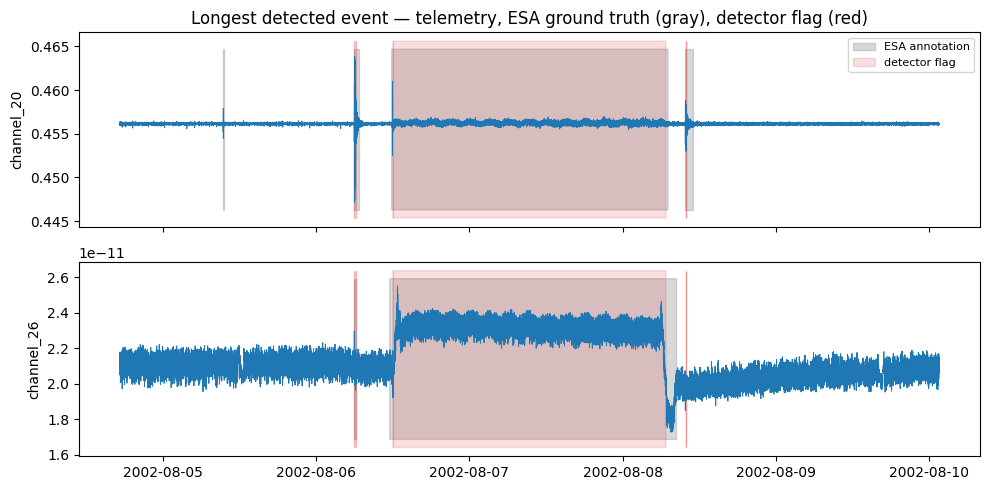

In [66]:
# The detection on real telemetry: longest predicted anomalous stretch, chosen
# programmatically from the detector's own output (no hand-picked indices).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

flags = np.loadtxt(SCORES_TEST, delimiter=",")            # detector 0/1 per test point
edges = np.flatnonzero(np.diff(np.r_[0, flags, 0]))       # run boundaries
starts, ends = edges[::2], edges[1::2]
k = int(np.argmax(ends - starts))                         # longest predicted event
pad = ends[k] - starts[k]
lo, hi = max(0, starts[k] - pad), min(len(flags), ends[k] + pad)

seg = pd.read_csv(config.TEST_CSV, skiprows=range(1, lo + 1), nrows=hi - lo)
seg["timestamp"] = pd.to_datetime(seg["timestamp"])
pred = flags[lo:hi].astype(bool)

# plot the two channels with the most annotated anomaly in this stretch
anno_cols = [f"is_anomaly_{c}" for c in config.TARGET_CHANNELS]
top2 = (seg[anno_cols] > 0).sum().nlargest(2).index
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, col in zip(axes, top2):
    ch = col.replace("is_anomaly_", "")
    truth = (seg[col] > 0).to_numpy()
    ax.plot(seg["timestamp"], seg[ch], lw=0.7, color="tab:blue")
    ax.fill_between(seg["timestamp"], *ax.get_ylim(), where=truth,
                    color="gray", alpha=0.3, label="ESA annotation")
    ax.fill_between(seg["timestamp"], *ax.get_ylim(), where=pred,
                    color="tab:red", alpha=0.15, label="detector flag")
    ax.set_ylabel(ch)
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Longest detected event — telemetry, ESA ground truth (gray), detector flag (red)")
plt.tight_layout()
plt.show()


### Why it is built this way: design decisions

1. **Vendor, never re-implement.** The detector, the preprocessing and the metric are
   ESA's own files, byte-identical (see `NOTICE`). Reproducing 0.949 with their code is
   *evidence*; re-implementing it would only prove we can introduce bugs.
2. **`subsequence_if` is the *standard* Isolation Forest**, not the Extended variant.
   ESA also ships `subsequence_eif` (one letter away, a different algorithm, not used
   in this benchmark). Documented because the confusion is expensive.
3. **Verify the data before trusting any result.** The preprocessing output was checked
   against ESA's shipped metadata (grid lengths, anomaly lengths, split boundaries: 6
   external checks, see [docs/REPRODUCTION.md](../docs/REPRODUCTION.md)) *before*
   running any detector.
4. **Detector-agnostic by construction.** Modules 2 to 4 consume only the detector's
   *outputs* (a continuous score per window, the windowed data, a scoring function),
   never its internals. Swapping in a different detector, for example ESA's deep
   DC-VAE, means regenerating those artifacts, not rewriting the trust layer.

**One limitation drives the next section:** `predict()` emits a hard 0/1. It says
*"anomaly"* with the same face whether it is 99% sure or 51% sure. For an operator that
difference is everything. Quantifying it is Module 2's job.


## 2 · Uncertainty: from raw score to calibrated confidence

**The problem.** The detector's 0/1 flag, and even its internal score, says nothing an
operator can act on. The Isolation Forest score only *orders* windows by rarity, on an
arbitrary scale: it is not a probability, and "score = 0.13" means nothing by itself.

**The idea.** Instead of trusting the raw score, compare it against a reference of
known-normal behavior: how does this window rank among windows we are sure were normal?

**The tool: conformal p-values.** Take a large pool of windows known to be normal
(the *calibration set*) and score them all. For a new window with score $s$:

$$p = \frac{\#\{\text{calibration scores} \geq s\} + 1}{n_{\text{calib}} + 1}$$

Read it as: *"what fraction of certified-normal history looks at least this weird?"*
If the data are exchangeable (roughly: the normal calibration windows and the new
ones come from the same behavior), this p-value comes with a **distribution-free
guarantee**:
flagging when $p < \alpha$ produces at most an $\alpha$ rate of false alarms on normal
data, regardless of what the detector is or how the data are distributed. So α stops
being a magic threshold and becomes a **false-alarm budget** you choose. Note that the
p-value itself makes **no decision**: it is a threshold-free rank, and every window
gets one. No cut exists until α is chosen, three cells below.


**Step A: get the raw material.** M1's `predict()` is a binary, and a binary cannot be
calibrated (a yes/no has no degrees). But the forest internally holds a continuous
score (`decision_function`: how hard each window was to isolate). This cell re-scores
all ~3M test windows with the **same trained forest**, with no retraining. Its check
proves the scores are trustworthy: thresholding them at M1's internal cut gives back
M1's exact 0/1.


In [67]:
from m2_uncertainty import scores as m2_scores
import numpy as np

SCORES_CONT = config.CACHE_DIR / "scores_continuous.npy"

if SCORES_CONT.exists():
    print("[skip] Continuous scores found. To recompute: delete the file and re-run.")
    cont = np.load(SCORES_CONT)
else:
    print("[run ] Scoring all test windows with the M1 forest (decision_function)...")
    t0 = time.perf_counter()
    cont = m2_scores.compute_scores()
    m2_scores.verify(cont)   # incl.: thresholding these gives M1's exact 0/1 back
    np.save(SCORES_CONT, cont)
    TIMINGS["continuous_scores"] = time.perf_counter() - t0
    print(f"[done] {TIMINGS['continuous_scores']/60:.1f} min.")
print(f"{len(cont):,} window scores — continuous, ready to calibrate.")


[skip] Continuous scores found. To recompute: delete the file and re-run.
3,062,385 window scores — continuous, ready to calibrate.


**Step B: put every window on a calibrated scale.** Two moves, and *neither involves a
threshold, a model decision, or any α*. First the **split**: the test period is cut in
three chronological thirds (calibration / validation / final report), and windows are
marked "certified normal" purely from **ESA's human annotations**. Then **conformal**:
each window's score becomes its p-value, a rank against the 57k-window calibration
pool. Every window gets its "rarity percentile"; nothing is flagged yet.


In [68]:
from m2_uncertainty import split as m2_split, conformal as m2_conformal

t0 = time.perf_counter()
m2_split.build()             # thirds + normal-window mask + 1-of-17 selection
s = m2_conformal.build()     # calibration set + p-values (validation + test-final)
m2_conformal.verify(s)       # p in [0,1], hand-example exact, ~5% below 0.05
TIMINGS["split+conformal"] = time.perf_counter() - t0
print(f"[done] split + conformal p-values in {TIMINGS['split+conformal']:.0f} s.")


Split cached -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/split.npz
Calibration set -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/calib_scores.npy  (n=57735)
p (valid)       -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/p_valid.npy  (n=1020800)
p (test-final)  -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/p_test.npy  (n=1020793)

=== Phase 3 success-test ===
  (a) p in [0,1]       : [0.0000, 1.0000]  OK
  (b) monotone         : p decreasing in score  OK
  (c) hand example     : p(0.35 | [.1...5]) = 0.5000 == 0.5  OK
  (d) coverage (indep) : P(p<0.05) = 0.0486  (target 0.05, 95% CI [0.0475, 0.0525], n=28867)
      -> within CI: conformal math sound on same-epoch normals  OK
[done] split + conformal p-values in 3 s.


**Step C: choose where the alarm line goes.** Two things happen here. The **rolling**
variant recalibrates causally per block, because a fixed calibration ages (the
satellite of month 18 is not the satellite of month 1). And the **α tuning** sweeps a
grid of candidate alarm lines over the *validation* third, measuring event-wise F0.5
at each point, for both variants. This is the only optimization in the module, and it
happens *after* the p-values exist, never before.


In [69]:
import io, contextlib
from m2_uncertainty import rolling as m2_rolling, alpha as m2_alpha

t0 = time.perf_counter()
m2_rolling.build()           # causal recalibration (drift countermeasure)
with contextlib.redirect_stdout(io.StringIO()):   # grid search calls ESA's chatty metric
    a = m2_alpha.build()     # tune alpha on validation (F0.5), both variants
    m2_alpha.verify(a)
TIMINGS["rolling+alpha"] = time.perf_counter() - t0

a_star = a["a_fixed"] if a["winner"] == "fixed" else a["a_roll"]
print(f"[done] rolling + alpha tuning in {TIMINGS['rolling+alpha']/60:.1f} min.")
print(f"Winner variant: {a['winner']}   alpha* = {a_star:.1e}")
print(f"F0.5 at alpha* (validation): {max(a['best_fixed'], a['best_roll']):.3f}")


rolling p (valid)      -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/p_valid_rolling.npy  (n=1020800)
rolling p (test-final) -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/p_test_rolling.npy  (n=1020793)
[done] rolling + alpha tuning in 2.8 min.
Winner variant: fixed   alpha* = 2.0e-05
F0.5 at alpha* (validation): 0.868


**Step D: the final exam.** The final split (third 3) has been touched by no decision so
far. It is used exactly once. Before the numbers, what each one means:

- **Precision**: of the windows we flagged, how many were truly anomalies. High means
  few false alarms.
- **Recall**: of the real anomalies, how many we caught. High means few misses.
- **F0.5**: a single score combining the two, weighting **precision twice as much** as
  recall. This is ESA's benchmark score.
- **F2**: the same combination, weighting **recall twice as much**. The "miss nothing"
  face of the same result. We report it next to F0.5 so both sides are visible.

One more number matters: at our actual operating point α*, how often do we raise a
false alarm on data we *know* is normal? The conformal method bounds it, and here we
measure it directly on the final third.


In [70]:
import io, contextlib
import numpy as np
from m2_uncertainty import evaluate as m2_evaluate

# Final report on the untouched third (captured: ESA's metric is verbose).
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    m2_evaluate.evaluate()
report = buf.getvalue()
print(report[report.index("================ M2 FINAL REPORT"):report.index("=== Phase 5")])

# False alarms at our real operating point alpha*, on windows we KNOW are normal.
split = np.load(config.CACHE_DIR / "split.npz")
thirds, normal = split["window_third"], split["window_normal"]
alpha_star = float(np.load(config.CACHE_DIR / "alpha_choice.npz")["alpha_fixed"])
p_norm = np.load(config.CACHE_DIR / "p_test.npy")[normal[np.flatnonzero(thirds == 2)]]
false_alarms = int((p_norm < alpha_star).sum())
print(f"At the operating point alpha* = {alpha_star:.0e}:")
print(f"  {false_alarms} false alarms across {p_norm.size:,} known-normal windows (final third).")


================ M2 FINAL REPORT (test-final = third 3, once) ================
Winner variant: FIXED   alpha* = 2.00e-05   budget alpha = 0.05

  M2 @ alpha* (optimised for F0.5):
    marked 24901 windows (2.44%)
    precision=0.9912  recall=0.9417  F0.5=0.9809  F2=0.9512

  M2 @ budget alpha (guarantee story, expected weak F0.5):
    precision=0.0153  recall=0.9917  F0.5=0.0190  F2=0.0720

  Baseline M1 @ third-final (same ESAScores, fair ground):
    precision=0.9912  recall=0.9417  F0.5=0.9809  F2=0.9512
    NOTE: M2@alpha* ~= M1 here. The F0.5-optimal conformal cut (score > max normal-
    calibration ~ -0.003) nearly coincides with M1's contamination threshold (~0):
    ~99.97% point agreement, event-wise identical. M2 TIES M1 on F0.5, it does not
    beat it -- two independent threshold routes land in the same place (mutual sanity).

  Coverage on third-3 held-out normals (target 0.05):
    aggregate=0.0388 (n=57431)  per-block std=0.114 min=0.000 max=0.662
    -> aggregate near 

### Why it is built this way: design decisions

1. **Calibration must be clean, and we pay for it honestly.** The forest trained on
   the train period, so calibrating there would be biased (in-sample). Hence the
   test-period split you just saw. Chronological means zero leakage, but calibration
   and test then live in different epochs of the satellite, so drift weakens the
   guarantee. We do not assume it holds: we **measure it** (Step B: 4.86% ≈ the 5%
   promise). Drift only bites near that 5% budget, though. Since we actually operate far
   below it (α* ≈ 2e-5), drift never reaches our operating point, which is why Step D
   shows **zero** false alarms there. A rolling recalibration was built as insurance for
   anyone operating at the 5% guarantee; at the F0.5 point the fixed one already wins.
2. **Overlapping windows lie about sample size.** Neighboring windows share 16 of 17
   points; they are near-copies. Calibrating on all of them would fake a huge
   calibration set. We keep **1 window of every 17** (the independent ones): fewer,
   but honest.
3. **TWO alphas, because two jobs. And α is a consequence of your metric, not a
   physical truth.** The *guarantee* α (5%) controls false alarms per window; marking
   5% of ~3M windows means thousands of false events, so F0.5 ≈ 0. The benchmark
   instead scores per-event F0.5, which **weighs precision double**: every false event
   is expensive, so the optimizer only lets the most extreme windows fire. That is
   *why* α* sank to the p-value floor (≈ 2e-5) in Step C. Optimize F2 (recall-weighted)
   instead and α* rises: recall goes from 0.95 to 0.98, but precision collapses from
   0.85 to 0.61. Same p-values, different alarm line. **The metric you optimize
   chooses your α for you.** And the F0.5 point is strong, not degenerate: precision
   0.85 AND recall 0.95 on validation, flagging only 1.25% of windows. One number
   cannot do both jobs; pretending it can would be lying with statistics.
4. **F0.5 weighs precision double, but a missed anomaly usually hurts more than a
   false alarm.** We optimize F0.5 anyway, for two reasons: comparability with ESA's
   benchmark, and false-alarm fatigue is real (ignored alerts become missed anomalies
   via the human). But the report shows recall and F2 *next to it*, so the operator
   sees both faces and can slide α to their own operating point.
5. **Confidence means "false-alarm control", never "probability of anomaly".** A
   one-class detector cannot give P(anomaly) without a base rate. $1-p$ is confidence
   in rejecting "this is normal". We claim less, and what we claim is true.

**What the next section adds:** the alert now says *how much* to trust it, but not
*where to look*. Pointing at the responsible channels is Module 3's job.


## 3 · Attribution: which channels caused it

**The problem.** Module 2 tells the operator *how much* to trust an alarm, but not
*where to look*. With 11 channels (hundreds in a real mission) a bare "anomaly here"
still means opening every plot. Attribution answers: which sensors drove this detection?

**The tool: perturbation.** No new model, no SHAP. For a flagged window we ask the
detector a counterfactual, one channel at a time: *"if this channel had behaved
normally, how much less anomalous would you find this window?"* We replace the channel
with its normal baseline, re-score, and measure the drop. A big drop means that channel
carried the anomaly. This is the whole method, quoted from the module:

```python
# src/m3_attribution/attribute.py: contribution of each channel c
base = clf.decision_function(windows)          # anomaly score as-is
for c in range(11):
    pert = windows.copy()
    pert[:, c*17:(c+1)*17] = baseline[c]        # channel c -> its normal value
    contrib[:, c] = base - clf.decision_function(pert)   # how much c mattered
```

It is model-agnostic (it only calls `decision_function`, so it survives a detector
swap) and it catches *collective* anomalies, where no single channel is extreme but the
combination is impossible, which a raw-magnitude ranking misses.


**Step A: build the normal baseline.** The value each channel is reset to during
perturbation: the median per channel over the *normal* points of the calibration third (third 1).
A real, robust normal level, not zero.


In [71]:
from m3_attribution import baseline as m3_baseline
import numpy as np

BASELINE_NPY = config.CACHE_DIR / "m3_baseline.npy"
if BASELINE_NPY.exists():
    print("[skip] Baseline found. To recompute: delete data/cached/m3_baseline.npy.")
    base = np.load(BASELINE_NPY)
else:
    t0 = time.perf_counter()
    base = m3_baseline.compute_baseline()
    np.save(BASELINE_NPY, base)
    m3_baseline.verify(base)
    TIMINGS["m3_baseline"] = time.perf_counter() - t0
print(f"Normal baseline ready: one level per channel, shape {base.shape}.")


[skip] Baseline found. To recompute: delete data/cached/m3_baseline.npy.
Normal baseline ready: one level per channel, shape (11,).


**Step B: attribute every flagged window, then group into events.** Perturb each marked
window channel-by-channel (11 channels in one batched call), then group the marked
windows into events. The grouping gap (100 windows ≈ 30 min) is tuned so the count of
predicted events matches the real ones almost exactly. Output: one channel ranking per
event, which is what the operator triages.


In [72]:
from m3_attribution import aggregate as m3_aggregate

t0 = time.perf_counter()
events = m3_aggregate.build(gap=100)   # perturb marked windows + group into events
m3_aggregate.verify(events, gap=100)
TIMINGS["m3_attribute"] = time.perf_counter() - t0
print(f"\n{len(events)} events, each with a per-channel attribution ranking.")


Events cached -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/m3_events.json  (n=120, gap=100)

=== M3 Phase 3 success-test ===
  (a) event count      : 120 (gap=100)  OK
  (b) ranking+duration : all 120 events non-empty ranking, duration>0  OK
  (c) gap sensitivity  : {1: 478, 3: 211, 5: 177, 10: 148, 25: 131}
  (d) sample for F6    : 120 predicted events overlap a labeled event
      marked windows   : 24901  (2.44% of third 3)
      most-confident events (min_p asc):
        #0: 45w  1260s  min_p=1.73e-05  [channel_20(40%), channel_19(33%), channel_18(24%)]
        #1: 483w  9018s  min_p=1.73e-05  [channel_18(32%), channel_22(17%), channel_21(15%)]
        #2: 671w  12744s  min_p=1.73e-05  [channel_18(31%), channel_21(18%), channel_20(16%)]

120 events, each with a per-channel attribution ranking.


**Step C: does the attribution actually work?** The honest test. Against the per-channel
ground truth (`is_anomaly_channel_*`), how often is the top-ranked channel a true
culprit (hit@1), and how good are the top 3 (precision@3)? Compared head to head against
two baselines: ranking channels by raw magnitude, and random. This is where the method
earns its place or does not.


In [73]:
from m3_attribution import evaluate as m3_evaluate

res = m3_evaluate.build()
m3_evaluate.verify(res)   # HARD: perturbation must beat random; vs magnitude reported honestly



=== M3 Phase 6 success-test (attribution validity) ===
  evaluable events : 120  (skipped, no channel truth: 0)
  method           hit@1   prec@3
  perturbation     1.000    0.972
  magnitude        0.617    0.617
  random (E)       0.475    0.475
  HARD  perturbation > random : 1.000 > 0.475  OK
  vs magnitude : perturbation WINS


**Step D: see one event.** A heatmap of channel contribution over time for a
representative event, with the true culprits marked. A sanity check you can read at a
glance: the hottest channel in the figure is the ranking's #1.



=== M3 Phase 7 success-test ===
  figure written   : /Users/adoviguera/Documents/GitHub/Deterministic AI/docs/m3_attribution_example.png  (263 KB)  OK
  event shown      : #1 (9018s)
  hottest == #1    : channel_18 matches ranking top  OK
  true culprits    : ['18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28']


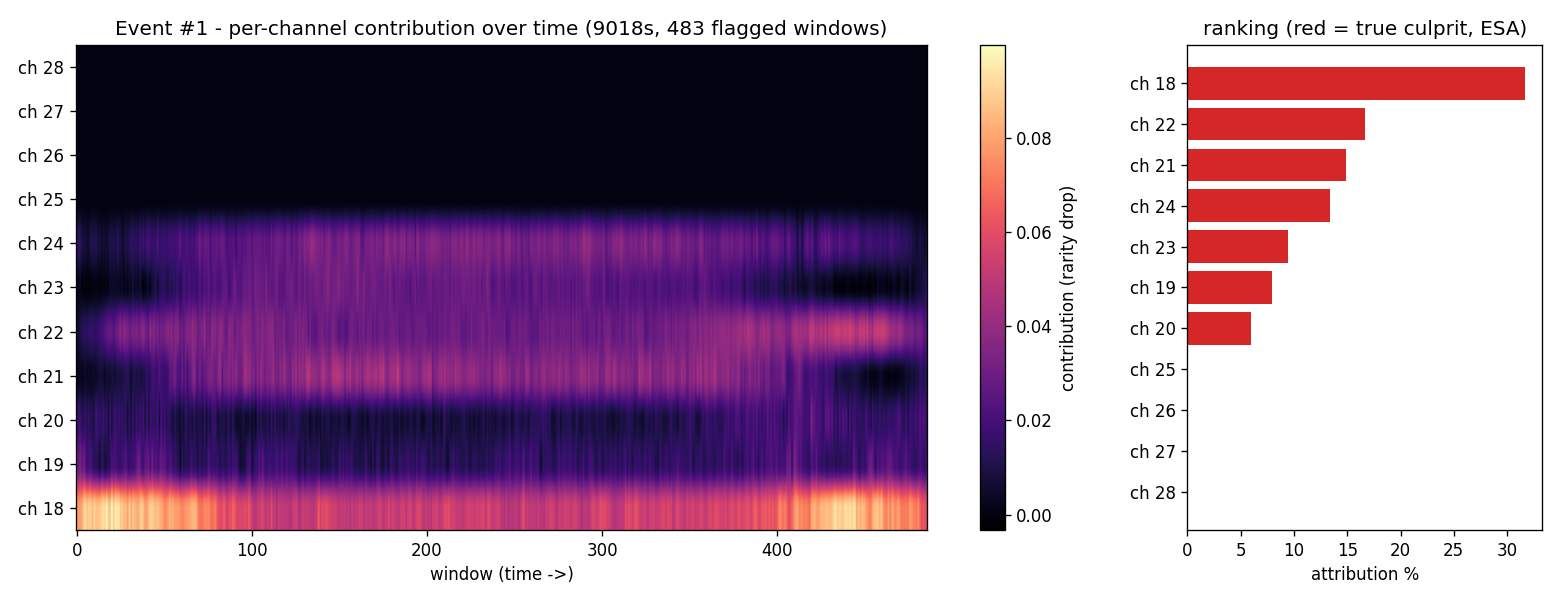

In [74]:
from m3_attribution import visualize as m3_visualize
from IPython.display import Image, display

res = m3_visualize.build()          # heatmap channel x time for a representative event
m3_visualize.verify(res)
display(Image(filename=str(m3_visualize.OUT_PNG)))


**Step E: assemble the grounded package for Module 4.** For each event, `context.build`
bundles exactly what the LLM is allowed to see: the M2 confidence, the ranked channels,
and their *relative* metadata relations (shared unit or group). No free text, every
field on a whitelist. This JSON is the handoff: the LLM writes from it, the judge audits
against it.


In [75]:
from m3_attribution import context as m3_context

contexts = m3_context.build()       # grounded per-event package for Module 4
m3_context.verify(contexts)
top = contexts[0]                   # highest priority first
print("\nHighest-priority event, packaged for Module 4:")
print(f"  event #{top['event_id']}  ({top['duration_sec']/3600:.1f} h, {top['n_windows']} windows)")
print(f"  M2 confidence : {top['m2_confidence']:.4f}   priority: {top['priority']:.3f}   ({top['localization']})")
print(f"  top channels  : {[c for c, _ in top['top_channels'][:3]]}")
print(f"  dominant      : {top['dominant_channels']}")
print(f"  shared hardware: {top['shared_relations']}")


Contexts cached -> /Users/adoviguera/Documents/GitHub/Deterministic AI/data/cached/m3_event_contexts.json  (n=120)

=== M3 Phase 5 success-test ===
  (a) fields present   : all 120 events match the 13-field whitelist  OK
  (b) grounding        : confidence & priority recompute from source  OK  (no free text)
  (c) prioritised      : ordered by priority desc  OK
  (d) serialises       : JSON round-trips identically  OK
      localization     : 120 confident, 0 diffuse (M3 abstains on where)
      coupled hints    : 120 events flag channels sharing group/unit
      top-3 by priority:
        #33: prio=1.452  intensity=0.288  111168s  confident  [channel_18(31%), channel_23(18%), channel_22(18%)]
        #36: prio=1.449  intensity=0.287  111078s  confident  [channel_18(32%), channel_23(18%), channel_22(17%)]
        #30: prio=1.398  intensity=0.282  89424s  confident  [channel_18(33%), channel_22(18%), channel_23(18%)]

Highest-priority event, packaged for Module 4:
  event #33  (30.9 h, 

### Why it is built this way: design decisions

1. **Perturbation, not SHAP or magnitude.** Model-agnostic (respects the
   detector-agnostic seam), CPU, no new dependencies, and unlike ranking by raw
   deviation it captures *collective* anomalies where no single channel is extreme but
   the combination is impossible. The validation above proves it: perturbation hit@1
   near 1.0 versus magnitude near 0.62.
2. **Baseline = median of real normal windows**, not zero and not a flat constant.
   Flattening a channel to a constant kills its variance, and a dead-flat line can look
   anomalous for its own reason, poisoning the measurement. Using a real normal level
   avoids that (a documented risk, checked in the module's `verify`).
3. **Attribute per window, aggregate to event.** The operator triages events, and ESA's
   metric is event-wise, so per-window attribution is summed into a per-event channel
   profile.
4. **Anonymized channels, so relative grounded hypotheses only.** The channel metadata
   is anonymized (subsystem_1, group_2, ...), so Module 3 prepares *relative* context
   ("channels 22 and 23 share physical_unit_9, so a coupled fault is plausible"), never
   an absolute cause. Module 3 only assembles grounded context; the LLM writes and the
   judge audits, in Module 4.

**What the next section adds:** we now have, per event, a calibrated confidence (M2) and
a ranked list of responsible channels with their shared-hardware relations (M3).
Module 4 turns that evidence into a readable operator brief, and a second LLM judges it
against the very same evidence, blocking anything not grounded.


## 4 · Trustworthy alert: grounded brief + LLM judge

This is the differentiator. Detection, uncertainty and attribution are now in hand; the
job of this layer is to turn that evidence into something an operator can read, without
letting a language model invent anything.

The design is **two moments, two tools**:

1. **The event OPENS.** Only its first flagged window exists. Reasoning would be
   premature and the downlink budget is tiny, so the alert is a **deterministic template**
   over that one window: no model, no retrieval, sent immediately.
2. **The event CLOSES.** Now the full picture exists (duration, every channel, the
   aggregated attribution from Module 3). There is time to reason, so this alert is a
   **retrieval plus a single generated paragraph, audited by a second model**.

Two rules make it trustworthy. The language model generates exactly **one thing**, the
prose paragraph: every number stays in deterministic tables built verbatim from Modules
2 and 3, so there is nothing for the model to fabricate. And the paragraph must clear
**two guardrails in series**: a lexical precheck (deterministic) and an LLM judge
(semantic). The verdict is the AND of both.

We walk one event end to end (event 33, the highest-priority one), then measure the
judge against a labelled golden set.

**Step A: one event through its two moments.** We follow event 33 across its lifecycle.
When it **opens**, only its first flagged window exists, so the START flag is a
deterministic template over that window: sent immediately, no model, no retrieval. When
it later **closes**, Module 3's aggregated package exists (duration, every channel, the
dominant ones), and that fuller picture is what the reasoning at close will use. The two
cells below show each moment: the opening flag, then the closed event.

In [76]:
from m4_report import start_window, alert

EVENT_ID = 33  # the highest-priority event; used as the worked example through Module 4

# First-window attribution: time-cost only, so it is generated on your machine once and
# reused (the Module 1 pattern). Delete the file to force a rebuild.
if not start_window.START_JSON.exists():
    print("building first-window attribution (needs model.pkl; ~seconds)...")
    start_window.build()
else:
    print(f"[skip] first-window records already built ({start_window.START_JSON.name}); delete to force")

records = alert.load_start_windows()
flag = alert.start_flag(records[EVENT_ID])

print("\nMOMENT ONE, the event opens. START flag (deterministic template, no LLM):")
print("  " + alert.render_flag(flag))
print(f"\nflag channels come from the FIRST window only: {flag['channels']}")

[skip] first-window records already built (m4_start_windows.json); delete to force

MOMENT ONE, the event opens. START flag (deterministic template, no LLM):
  ANOMALY START t=2002-12-31T05:13:12 | ch 20,18,19 | intensity high (score 0.002) | conf>0.9999 (saturated)

flag channels come from the FIRST window only: ['channel_20', 'channel_18', 'channel_19']


In [77]:
from m4_report.generation.generator import load_contexts
from m4_report import prompts

contexts = {c["event_id"]: c for c in load_contexts()}   # Module 3's closed-event packages
ctx = contexts[EVENT_ID]
all_flagged = [c for c, _ in ctx["top_channels"]]

print(f"MOMENT TWO, the event has closed. Now the full picture exists:")
print(f"  duration     : {prompts.human_duration(ctx['duration_sec'])}  ({ctx['n_windows']} windows)")
print(f"  all channels : {all_flagged}")
print(f"  dominant     : {ctx['dominant_channels']}")
print(f"  localization : {ctx['localization']}   priority: {ctx['priority']:.2f}")
print(f"\ncontrast with moment one: the flag saw only {flag['channels']} (first window).")
print("the aggregated view is richer and different, proof the flag used no future information.")

MOMENT TWO, the event has closed. Now the full picture exists:
  duration     : 30 h 52 min 48 s  (6161 windows)
  all channels : ['channel_18', 'channel_23', 'channel_22', 'channel_21', 'channel_24', 'channel_20', 'channel_19']
  dominant     : ['channel_18', 'channel_23', 'channel_22', 'channel_21']
  localization : confident   priority: 1.45

contrast with moment one: the flag saw only ['channel_20', 'channel_18', 'channel_19'] (first window).
the aggregated view is richer and different, proof the flag used no future information.


**Step B: retrieve similar past anomalies.** Only at close, with the full channel set in
hand, we match the event against a corpus of 644 past anomalies using a weighted Tversky
index (a set-overlap score), with no embeddings and no vector database: the whole
retrieval is explainable arithmetic. Two safeguards. It considers only past anomalies
that **ended before this event started**, so it characterises what the event resembles
without ever peeking at its own label. And it reports **novelty**, how unlike anything in
the archive the channel combination is, as an honest signal rather than a hidden score.

In [78]:
from m4_report.retrieval import retrieve as m4_retrieve

# load_corpus() builds m4_anomaly_corpus.json from labels.csv on first call, then reuses it.
corpus = m4_retrieve.load_corpus()
result = m4_retrieve.retrieve(ctx, corpus)   # weighted Tversky over channel sets; live arithmetic

print(f"combination novelty: {result['novelty']:.3f}   (0 = seen before, 1 = unlike anything past)")
print("closest past anomalies (all ended before this event started):")
for nb in result["neighbors"][:3]:
    print(f"  {nb['id']}  similarity={nb['sim']:.3f}  class={nb['class']}  category={nb['category']}")

combination novelty: 0.102   (0 = seen before, 1 = unlike anything past)
closest past anomalies (all ended before this event started):
  id_638  similarity=0.898  class=class_22  category=Rare Event
  id_326  similarity=0.800  class=class_23  category=Rare Event
  id_116  similarity=0.769  class=class_19  category=Rare Event


**Step C: the single generated paragraph.** The model receives only narrative-shaped
evidence: names (channels, groups, physical units), qualitative words, a human-readable
duration and a confidence percentage. Precise measurements never reach it, so it cannot
alter them; they live in the tables. Note where retrieval enters: the evidence carries
only the qualitative word from Step B (here "familiar"), never the neighbor ids or
similarities, which stay in the similar-anomalies table. The brief is the one thing the
language model produces.

In [79]:
from m4_report import prompts

# The ONLY material the model sees, shown in full. The "archive" block at the end is the
# only place Step B's retrieval enters, and only as the qualitative word "familiar"; the
# neighbor ids and similarities stay out (they live in the tables).
evidence = prompts.evidence_block(ctx, result)
print("EVIDENCE handed to the model (names and words only, no precise numbers):\n")
print(evidence)

EVIDENCE handed to the model (names and words only, no precise numbers):

EVIDENCE (use ONLY these facts):
{
  "event": {
    "status": "closed -- the detector stopped flagging windows (says nothing about the underlying issue being resolved)",
    "localization": "confident",
    "dominant_channels": [
      "channel_18",
      "channel_23",
      "channel_22",
      "channel_21"
    ],
    "all_flagged_channels": [
      "channel_18",
      "channel_23",
      "channel_22",
      "channel_21",
      "channel_24",
      "channel_20",
      "channel_19"
    ],
    "coupling_note": "hypothesis (unconfirmed): channel_23, channel_22, channel_21 share group_2 (group); channel_23, channel_22, channel_21 share physical_unit_9 (unit) -- a coupled behaviour is possible",
    "duration": "30 h 52 min 48 s",
    "confidence": "99.998 %",
    "confidence_note": "confidence is saturated (near its ceiling) across ALL flagged events; it does not rank or discriminate between events -- use the priority

**Choose how the brief is produced, before generating it.** By default the next cell
reads the committed LLM cache (`ESA_LLM_USE_CACHE` is true), so the brief reproduces
exactly with no API key. The cache is not about saving money (the model is free to run):
a language model is not bit-deterministic even at temperature zero, so the committed
response is the canonical reference. To generate live against Groq instead, uncomment the
cell below now (a live re-roll may differ slightly from the cached reference, which is
expected). Leave it as is to stay offline.

In [80]:
# OPTIONAL: generate the brief live instead of reading the committed cache. Run this
# BEFORE the next cell.
# 1. Get a free API key at https://console.groq.com
# 2. Put it in .env as GROQ_API_KEY, then uncomment:
#
# import os
# os.environ["ESA_LLM_USE_CACHE"] = "false"

In [81]:
import textwrap
from m4_report.generation.generator import generate_brief

# The single LLM output, honoring the mode chosen above. A lexical precheck runs inside
# generate_brief and raises on any fabricated token. Wrapped so it fits the console.
brief = generate_brief(ctx, result)
print("BRIEF (the one generated paragraph, precheck already passed):\n")
print(textwrap.fill(brief, width=88))

BRIEF (the one generated paragraph, precheck already passed):

The event is now closed -- the detector stopped flagging windows (says nothing about the
underlying issue being resolved). Localization is confident and the dominant channels
are channel_18, channel_23, channel_22, and channel_21. All flagged channels include
channel_18, channel_23, channel_22, channel_21, channel_24, channel_20, and channel_19.
hypothesis (unconfirmed): channel_23, channel_22, channel_21 share group_2 (group);
channel_23, channel_22, channel_21 share physical_unit_9 (unit) -- a coupled behaviour
is possible. The anomaly persisted for 30 h 52 min 48 s with a confidence of 99.998 %;
confidence is saturated (near its ceiling) across ALL flagged events; it does not rank
or discriminate between events -- use the priority value in the facts table. The channel
combination is familiar; derived deterministically from how much this event's CHANNEL
COMBINATION matches past anomalies; it says nothing about magnitude o

**Step D: two guardrails in series.** The brief only ships if it clears both, so the
verdict is their AND. They catch different failures, so each has its own cell below.

- **Guardrail 1, precheck (lexical, deterministic, no model).** Every citable token in
  the brief (a channel, a past-anomaly id, a number, a timestamp) must appear literally
  in the evidence. It is free and exact, and it already ran inside Step C. It cannot see
  a hallucination that invents no token.
- **Guardrail 2, judge (semantic, a second model).** It audits the brief claim by claim
  against the same evidence, told to refute. It catches what the precheck cannot: a
  stated root cause, a hypothesis sold as fact, an overclaim of certainty, a
  "resembles a thermal fault" with no false token. PASS and FLAG ship the brief; BLOCK
  withholds it.

In [82]:
from m4_report.guardrails.precheck import precheck

# Guardrail 1 on the real brief: it passes (nothing cited that is not in the evidence).
print("precheck on the real brief:", precheck(brief, evidence))

# Inject a fabricated channel that is nowhere in the evidence: the precheck names it.
fabricated = brief + " channel_99 also fired."
print("precheck with a fabricated channel_99:", precheck(fabricated, evidence))

precheck on the real brief: {'passed': True, 'offending': []}
precheck with a fabricated channel_99: {'passed': False, 'offending': ['channel_99']}


In [83]:
from m4_report.guardrails.judge import judge
from m4_report.evals.run_eval import run as run_golden

# Guardrail 2 on the real brief: fully grounded, so it passes.
verdict = judge(brief, evidence)
print(f"judge verdict on event {EVENT_ID}: {verdict.verdict}")
print(f"  reasons: {verdict.reasons or 'none (every claim grounded in the evidence)'}")

# Who watches the watchman: the judge golden (clean must pass, dirty must block). Cached.
g = run_golden()
print(f"\njudge golden: precision {g['precision']:.2f} (clean approved), "
      f"recall {g['recall']:.2f} (dirty blocked)")
print(f"  over {g['n_clean']} clean + {g['n_dirty']} dirty hand-labelled cases")
print("\nsample hallucinations the judge blocks (invisible to the precheck):")
for r in g["results"]:
    if r["expected"] == "BLOCK" and r["id"] in ("D2", "D5", "D9"):
        print(f"  [{r['id']}] {r['got']}: {r['tests'][:62]}")

judge verdict on event 33: PASS
  reasons: none (every claim grounded in the evidence)

judge golden: precision 1.00 (clean approved), recall 1.00 (dirty blocked)
  over 7 clean + 11 dirty hand-labelled cases

sample hallucinations the judge blocks (invisible to the precheck):
  [D2] BLOCK: semantic hallucination with NO false token (the judge's reason
  [D5] BLOCK: leakage: cites a past anomaly that is not in the evidence
  [D9] BLOCK: resolution claim (closed means only that flagging stopped)


### Why it is built this way: design decisions

Told in the order the system actually runs.

1. **Two moments, two tools.** A dumb fast template the instant the event opens (latency
   zero, tiny downlink, no future information); a reasoned brief only at close, when the
   full picture exists. Reasoning early would be premature and would leak the event's own
   future into the opening alert.
2. **At close, retrieval is deterministic, not a vector database.** A weighted Tversky
   index over channel sets: explainable, reproducible, edge-friendly, auditable, and
   restricted to past anomalies that ended before the event (anti-leakage). A vector
   database is noted as future work for free-text knowledge (manuals, procedures).
3. **The model only narrates; every number is deterministic.** The design target is a
   small model running on board, so instead of buying a bigger model we shrink the
   probabilistic surface: the prose is simplified to the minimum and all figures live in
   verbatim tables, never passing through the model. The few qualitative words
   ("familiar", the readable duration, the coupling sentence) are computed by fixed rules
   and the model only repeats them. Tradeoff accepted: less rich prose in exchange for
   prose that cannot lie.
4. **Channels are anonymized, so the brief offers relative coupling hypotheses, never a
   root cause.** The dataset gives no channel semantics, so the system cannot and must
   not diagnose a cause. It states only what shared hardware allows ("these channels
   share a group, a coupled fault is possible"), always labelled as an unconfirmed
   hypothesis.
5. **Confidence is reported as saturated, never sold as discriminating.** It sits near
   its ceiling for every flagged event (the alpha* floor from Module 2), so the brief
   says so and points to priority instead. The judge blocks any certainty overclaim.
6. **The prompt is versioned and event-blind.** No event-specific data ever enters the
   prompt, only system vocabulary, and a shipped prompt version is never edited. The
   generator was hardened on a held-out set: a minimal "quote, do not paraphrase" fix
   took the run from 116/120 to 120/120 without breaking the ones that already passed.
7. **Two guardrails in series, verdict is the AND.** A lexical precheck (free, catches
   fabricated tokens and numbers) then an LLM judge (catches semantic hallucination with
   no false token). Neither alone is enough.
8. **The judge is evaluated before it is trusted.** A golden set of 18 diverse
   human-labelled cases (7 clean it must pass, 11 dirty covering each violation type)
   gives precision 1.0 and recall 1.0. Declared as an existence proof over 18 cases, not
   a statistical guarantee.
9. **The committed cache is a reproducibility device, not a cost saver.** The model is
   free to run, but it is not bit-deterministic even at temperature zero, so the frozen
   response is the canonical reference. Anyone can regenerate live with a key; the
   time-only artifacts regenerate on the user's machine on first run and are then reused.

**What the next section adds:** here we dissected one event statically. The streaming
simulation replays the whole mission timeline in order, with no lookahead, firing these
two moments as events open and close, and reports the downlink reduction (and the
generator's PASS/FLAG/BLOCK scorecard over all 120 events) that makes the layer worth
putting on board.

## 5 · Live streaming simulation

Section 4 dissected one event standing still. This section puts the whole thing in
motion, because an alert that only works on a finished, tidy dataset is not an alert.

The core is a **state machine** that consumes one window at a time and **never looks
ahead**: at window N it knows only windows up to N. A window far enough from the last
flagged one closes the open event and opens the next. Opening fires moment one (the
deterministic flag), closing fires moment two (retrieval, brief, both guardrails).

Batch and live differ **only in the driver that feeds the machine**: here a loop over the
replayed detector output, on board a loop over a live feed. The machine cannot tell the
difference, which is the point.

**Declared assumption, not a claim:** ESA-ADB is a ground benchmark (historical telemetry,
already annotated). We validate on the ground and design to run on board. The deployment
is argued, not certified.

**Step A: pick a period of the mission, then watch the machine run it.**

An operator does not get to say "show me event 3". They watch a **period of mission time**
and the events appear, or do not. So that is what you choose here: a start date and a
number of days. The machine is told nothing about where the events are; it discovers them
as the windows arrive.

- **`START`** and **`DAYS`** select the stretch of mission clock to replay. Modules 2 to 4
  operate on the final third of the test set, so the replayable stretch begins in December
  2002. Earlier mission dates are out of scope, not quiet: nothing before that was scored.
- **`SPEED`** is how many flagged windows tick per second on screen. Lower it to follow
  along, raise it to fast-forward.

Only flagged windows tick, and the quiet stretches between them are named as they pass. If
your period runs out while an event is still open, the machine says so and produces **no**
closing alert: it has not seen the event end, and inventing the ending is exactly the
lookahead this design refuses. This is a slice for the eyes only, not a toy machine:
`pipeline.replay()` is reused verbatim, and it is the same machine we turn loose on the
entire mission in Step C.

In [84]:
import numpy as np
import pandas as pd

from m4_report import pipeline
from m4_report.alert import load_start_windows
from m2_uncertainty.split import load_timestamps

# ---- the knobs: pick a period of the mission, the way an operator would ----
START = "2003-01-10"   # mission date to start the replay from
DAYS = 10              # how many days of mission time to replay
SPEED = 20.0           # flagged windows per second on screen
# ---------------------------------------------------------------------------

ts = load_timestamps()
start_records = load_start_windows()                    # first-window facts, one per event
flagged = np.array(list(pipeline.flagged_stream()))     # the windows the detector flagged
t_flagged = ts.values[flagged]

# Which event owns which flagged window, and where each event really ends. The machine
# never uses this; it is only so the notebook can label what you are seeing.
first_of = np.array([start_records[e]["window_idx"] for e in sorted(start_records)])
_bounds = np.searchsorted(flagged, np.append(first_of, flagged[-1] + 1))
last_of = {e: int(flagged[_bounds[e + 1] - 1]) for e in range(len(first_of))}


def owner(idx):
    """The event a flagged window belongs to (a period may start inside one)."""
    eid = int(np.searchsorted(first_of, idx, side="right") - 1)
    assert 0 <= eid < len(first_of), f"window {idx} belongs to no event"
    return eid


def period(start, days):
    """The flagged windows that fall inside a period of mission time."""
    t0 = pd.Timestamp(start)
    t1 = t0 + pd.Timedelta(days=days)
    return t0, t1, flagged[(t_flagged >= t0) & (t_flagged < t1)]


def on_screen(stream, speed):
    """Rough wall time: one tick per window, plus a pause on each open and each close."""
    n_events = len({owner(int(i)) for i in stream})
    return len(stream) / speed + 2.0 * n_events


t0, t1, window_stream = period(START, DAYS)
scored_from, scored_to = pd.Timestamp(t_flagged[0]), pd.Timestamp(t_flagged[-1])

print(f"replayable stretch: {scored_from} to {scored_to}")
print("  (Modules 2 to 4 run on the final third of the test set. Earlier mission dates are")
print("   out of scope, not quiet: nothing before this was ever scored.)")

print(f"\nyour period: {t0.date()} to {t1.date()}")
if len(window_stream) == 0:
    print("  nothing flagged here. Either the period is out of scope (before December 2002),")
    print("  or the detector saw nothing worth flagging. Pick another START above.")
else:
    print(f"  {len(window_stream)} windows flagged, about {on_screen(window_stream, SPEED):,.0f} s "
          f"on screen at SPEED={SPEED:g}")
print("  the machine is not told where the events are; it discovers them as it goes.")

print("\nother periods to try (DAYS = 10):")
for d in ("2002-12-01", "2003-02-15", "2003-04-01", "2003-06-01"):
    _, _, s = period(d, 10)
    print(f"  {d}   {len(s):>5} flagged windows, about {on_screen(s, SPEED):,.0f} s")
print("  2001-11-01   out of scope (before the scored third): the machine would see nothing")

replayable stretch: 2002-12-01 00:20:06 to 2003-06-30 05:53:24
  (Modules 2 to 4 run on the final third of the test set. Earlier mission dates are
   out of scope, not quiet: nothing before this was ever scored.)

your period: 2003-01-10 to 2003-01-20
  106 windows flagged, about 13 s on screen at SPEED=20
  the machine is not told where the events are; it discovers them as it goes.

other periods to try (DAYS = 10):
  2002-12-01    1408 flagged windows, about 86 s
  2003-02-15     100 flagged windows, about 13 s
  2003-04-01     157 flagged windows, about 18 s
  2003-06-01      64 flagged windows, about 9 s
  2001-11-01   out of scope (before the scored third): the machine would see nothing


In [85]:
import time
from IPython.display import clear_output

from m4_report.alert import start_flag, render_flag
from m4_report.retrieval.retrieve import load_corpus
from m4_report.generation.generator import load_contexts

contexts = {c["event_id"]: c for c in load_contexts()}
corpus = load_corpus()

log = []
closed_alerts = {}            # the alerts the machine actually produced during this replay
clock = {"idx": None}         # the latest window the machine has seen. It never goes back.


def show(note=""):
    idx = clock["idx"]
    clear_output(wait=True)
    print(f"replaying {t0.date()} to {t1.date()}    SPEED = {SPEED:g} windows/s")
    print(f"mission clock: {ts.iloc[idx]}    window {idx:>9,}   {note}")
    print("-" * 78)
    for line in log:
        print(line)


def paced(indices):
    """The DRIVER: hand the machine one window at a time. On board this is a live feed."""
    previous = None
    for i in indices:
        i = int(i)
        now = ts.iloc[i]
        if previous is not None and now - previous > pd.Timedelta(hours=1):
            log.append(f"[quiet] {now - previous} with nothing flagged")
        previous = now
        clock["idx"] = i          # the clock only ever moves forward
        show()
        yield i                   # the machine consumes it; it never looks ahead
        time.sleep(1.0 / SPEED)


def on_open(first_idx):
    eid = owner(first_idx)
    if first_idx == start_records[eid]["window_idx"]:     # the event opened inside our period
        log.append(f"[open ] event {eid}: {render_flag(start_flag(start_records[eid]))}")
    else:                                                 # it was already running when we tuned in
        log.append(f"[open ] event {eid}: already in progress when the period began")
    show("EVENT OPENS")
    time.sleep(1.0)


def on_close(first_idx, last_idx):
    eid = owner(first_idx)
    if last_idx != last_of[eid]:
        # The period ran out while the event was still going. The machine has NOT seen it
        # end, so it has no closing brief: the archived context describes windows it never
        # saw, and using it here would be exactly the lookahead this design refuses.
        log.append(f"[  ...] event {eid}: still open when the period ended, no closing alert")
        show("PERIOD ENDS, EVENT STILL OPEN")
        return
    closed = pipeline.close_event(contexts[eid], corpus)  # retrieval + brief + precheck AND judge
    closed_alerts[eid] = closed
    mark = "brief WITHHELD" if closed["verdict"] == "BLOCK" else "brief cleared"
    log.append(f"[close] event {eid}: verdict {closed['verdict']} ({mark})")
    show("EVENT CLOSES")
    time.sleep(1.0)


if len(window_stream) == 0:
    print("nothing flagged in this period. Pick another START in the cell above.")
else:
    # The SAME state machine that runs the full mission. Only the driver differs.
    pipeline.replay(paced(window_stream), on_open, on_close)
    print("\n" + "-" * 78)
    print(f"replayed {len(window_stream)} flagged windows of {t0.date()} to {t1.date()}: "
          f"{len(closed_alerts)} event(s) closed and audited.")

replaying 2003-01-10 to 2003-01-20    SPEED = 20 windows/s
mission clock: 2003-01-19 14:00:00    window 2,282,800   EVENT CLOSES
------------------------------------------------------------------------------
[open ] event 48: ANOMALY START t=2003-01-10T16:14:24 | ch 20,19,18 | intensity high (score -0.003) | conf>0.9999 (saturated)
[quiet] 2 days 23:48:36 with nothing flagged
[close] event 48: verdict PASS (brief cleared)
[open ] event 49: ANOMALY START t=2003-01-13T16:22:12 | ch 18,20,19 | intensity high (score -0.002) | conf>0.9999 (saturated)
[quiet] 2 days 23:46:30 with nothing flagged
[close] event 49: verdict PASS (brief cleared)
[open ] event 50: ANOMALY START t=2003-01-16T16:11:42 | ch 20,19,18 | intensity high (score 0.002) | conf>0.9999 (saturated)
[quiet] 2 days 21:37:48 with nothing flagged
[close] event 50: verdict PASS (brief cleared)
[open ] event 51: ANOMALY START t=2003-01-19T13:52:48 | ch 20,19,18 | intensity high (score 0.007) | conf>0.9999 (saturated)
[close] event 

**Step B: the alert the operator actually receives.** This is one of the alerts the machine
just produced, taken straight from the replay above (not recomputed for the demo). A facts
table lifted verbatim from Modules 2 and 3, the retrieved past anomalies, and the one
audited paragraph. The figures are not written by the model; only the prose is, and it has
cleared both guardrails.

In [86]:
from IPython.display import Markdown, display

if not closed_alerts:
    print("no event closed inside this period, so there is no closing alert to show.")
    print("Pick a period that fully contains an event (try START = '2003-01-10', DAYS = 10).")
else:
    demo_id = max(closed_alerts)                    # the last event the machine closed
    print(f"the closing alert for event {demo_id}, exactly as the replay emitted it:\n")
    display(Markdown(closed_alerts[demo_id]["alert_md"]))

the closing alert for event 51, exactly as the replay emitted it:



## Anomaly event 51 -- closing brief

### Facts (verbatim from the detection pipeline)

| fact | value (verbatim from M3) |
|---|---|
| event_id | `51` |
| start | `"2003-01-19T13:52:48"` |
| end | `"2003-01-19T14:04:48"` |
| duration_sec | `720.0` |
| m2_confidence | `0.9999826797838437` |
| priority | `0.0781669265793313` |
| intensity | `0.027350838748618458` |
| localization | `"confident"` |
| dominant_channels | `["channel_20", "channel_19", "channel_18"]` |
| top_channels | `[["channel_20", 41.66572064469467], ["channel_19", 27.955840680022227], ["channel_18", 20.798802575422027], ["channel_23", 5.3204995440533995], ["channel_22", 3.580224804007189], ["channel_21", 0.6789117518004804]]` |

note: m2_confidence saturates (~1 for every flagged event; alpha* floor) -- it does not rank events. Use priority.

### Similar past anomalies (retrieved, all ended before this event)

| past anomaly | similarity | shared channels |
|---|---|---|
| id_616 | 0.786 | channel_18, channel_19, channel_20 |
| id_553 | 0.786 | channel_18, channel_19, channel_20 |
| id_44 | 0.786 | channel_18, channel_19, channel_20 |
| id_406 | 0.786 | channel_18, channel_19, channel_20 |
| id_194 | 0.786 | channel_18, channel_19, channel_20 |

combination novelty: 0.214 (1 = channel set unlike anything in the archive)

### Brief (LLM-generated, audited)

The event is now closed – the detector stopped flagging windows. Localization is confident, with the dominant channels being channel_20, channel_19, and channel_18. The full set of flagged channels also includes channel_23, channel_22, and channel_21. hypothesis (unconfirmed): channel_20, channel_19, channel_18 share group_5 (group) -- a coupled behaviour is possible. The anomaly persisted for 12 min with a confidence of 99.998 % and confidence is saturated (near its ceiling) across ALL flagged events; it does not rank or discriminate between events -- use the priority value in the facts table. The channel combination is somewhat familiar, meaning it matches past anomalies to a moderate degree but this says nothing about magnitude or severity.


**Step C: the same machine, now over the whole mission.** No animation this time, just
the complete timeline: all 120 events, each opening with a flag and closing with an
audited alert. The scorecard is the generator's real result, judged by both guardrails on
every event, not on a hand-picked example.

In [87]:
import io, contextlib

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    alerts = pipeline.run()        # same state machine, whole timeline, offline (~1 s)

counts = {v: sum(1 for a in alerts.values() if a["verdict"] == v) for v in ("PASS", "FLAG", "BLOCK")}
print(f"whole mission replayed: {len(alerts)} events, each opened with a flag "
      f"and closed with an audited alert.")
print(f"generator scorecard: {counts['PASS']} PASS, {counts['FLAG']} FLAG, {counts['BLOCK']} BLOCK")

whole mission replayed: 120 events, each opened with a flag and closed with an audited alert.
generator scorecard: 120 PASS, 0 FLAG, 0 BLOCK


**Step D: what ships when the guardrail blocks.** On this mission no real brief was
blocked (all 120 passed), so we do not pretend otherwise. The BLOCK path still has to
work, so we exercise it with a hallucination the judge caught in the golden set: an
invented root cause, written with no false token, which the lexical precheck cannot see.
The brief is withheld and never even stored. The deterministic tables still ship, along
with the judge's reasons, so the operator is told why the prose is missing rather than
being handed something untrue.

In [88]:
from m4_report.evals.run_eval import run as run_golden
from m4_report.generation.render import render_alert
from m4_report.retrieval.retrieve import retrieve

g = run_golden()
blocked = next(r for r in g["results"] if r["id"] == "D2")   # invented root cause, no false token
assert blocked["got"] == "BLOCK", f"golden case D2 was not blocked: {blocked['got']}"

# Render the alert that would have gone down in place of the hallucinated brief.
demo_id = max(closed_alerts) if closed_alerts else 33
ctx_d = contexts[demo_id]
withheld = render_alert(ctx_d, retrieve(ctx_d, corpus),
                        pipeline.WITHHELD + "\nJudge reasons: " + " | ".join(blocked["reasons"]))

print(f"judge verdict on the hallucinated brief: {blocked['got']}")
print("the brief is withheld and never stored; the tables and the reasons still go down.\n")
display(Markdown(withheld))

judge verdict on the hallucinated brief: BLOCK
the brief is withheld and never stored; the tables and the reasons still go down.



## Anomaly event 51 -- closing brief

### Facts (verbatim from the detection pipeline)

| fact | value (verbatim from M3) |
|---|---|
| event_id | `51` |
| start | `"2003-01-19T13:52:48"` |
| end | `"2003-01-19T14:04:48"` |
| duration_sec | `720.0` |
| m2_confidence | `0.9999826797838437` |
| priority | `0.0781669265793313` |
| intensity | `0.027350838748618458` |
| localization | `"confident"` |
| dominant_channels | `["channel_20", "channel_19", "channel_18"]` |
| top_channels | `[["channel_20", 41.66572064469467], ["channel_19", 27.955840680022227], ["channel_18", 20.798802575422027], ["channel_23", 5.3204995440533995], ["channel_22", 3.580224804007189], ["channel_21", 0.6789117518004804]]` |

note: m2_confidence saturates (~1 for every flagged event; alpha* floor) -- it does not rank events. Use priority.

### Similar past anomalies (retrieved, all ended before this event)

| past anomaly | similarity | shared channels |
|---|---|---|
| id_616 | 0.786 | channel_18, channel_19, channel_20 |
| id_553 | 0.786 | channel_18, channel_19, channel_20 |
| id_44 | 0.786 | channel_18, channel_19, channel_20 |
| id_406 | 0.786 | channel_18, channel_19, channel_20 |
| id_194 | 0.786 | channel_18, channel_19, channel_20 |

combination novelty: 0.214 (1 = channel set unlike anything in the archive)

### Brief (LLM-generated, audited)

**Brief withheld by the guardrail** (precheck AND judge must approve).
Judge reasons: root cause: "thermal regulation fault affecting the battery subsystem" (the brief states a physical cause, but evidence only localises where, not why) | unsupported claim: "The pattern is consistent with a thermal regulation fault" (no evidence of thermal fault or battery subsystem in the provided facts)


### Why it is built this way: design decisions

1. **A state machine with no lookahead.** At window N it knows only windows up to N, so
   nothing it decides could depend on the future. That is what makes the ground replay a
   fair rehearsal of a live feed rather than a demo that quietly cheats.
2. **Batch and live differ only in the driver.** The loop that feeds windows is the only
   thing that would change on board. `replay()` cannot tell which one is calling it, so
   the same tested code path serves both.
3. **The replay reuses the pipeline verbatim.** The notebook adds a pacer and a display
   and nothing else. If the demo had its own copy of the logic, the demo would be proving
   the demo, not the system.
4. **A blocked brief never ships.** The alert still goes out with its deterministic tables
   and the judge's reasons, so a guardrail failure degrades into an honest, quieter alert
   instead of a confident wrong one. Silence beats a lie, and a table beats silence.
5. **We show the BLOCK path even though it never fired.** All 120 briefs passed. Rather
   than manufacture a failure or quietly skip the case, we exercise the path with a
   hallucination from the golden set and say plainly that it is synthetic.

## 6 · Wrap-up: what this is *not*, future work, references

Everything above is honest about what it measured. This section is honest about what it
did **not** measure. Each item below is a **declared assumption**, which is a different
thing from a hidden one: the system is built on top of it in the open, and you can check
where it bites.

**On-board deployment is argued, not certified.** The design target is a small model
running on the spacecraft, and every choice in Module 4 points that way: the prose is the
only generated artifact, the numbers stay in deterministic tables, the retrieval is plain
arithmetic instead of a vector database. But nothing here was flown, power-budgeted or
radiation-qualified. In this demo the language model runs on Groq (a cloud API), which is
a **proxy** for the small on-premise model, not evidence that the small model would do the
job. The claim we make is "this is designed to fit on board", not "this fits on board".

**ESA-ADB is a ground benchmark.** It is historical telemetry that has already been
annotated by mission experts. The streaming replay in Section 5 is a fair rehearsal (the
state machine never looks ahead), but a rehearsal is not a flight. We validate on the
ground and design to go on board.

**The channels are anonymized, so there is no root-cause diagnosis.** The dataset gives no
semantics: `channel_22` is `channel_22`, not "battery bus voltage". The system therefore
never invents what a channel measures and never states why an anomaly happened. It does
three things: it **detects**, it **quantifies how much you should trust the detection**,
and it **localizes which channels drove it**. Any coupling statement it makes ("these
channels share a physical unit, so a coupled fault is possible") is labelled as an
unconfirmed hypothesis. The "why" is the operator's judgement, and the alert is built to
support that judgement rather than to replace it.

**The judge golden set is an existence proof, not a statistical guarantee.** Recall 1.0
means: over roughly 18 human-labelled, human-readable cases (7 clean, 11 dirty, one per
violation type), the judge caught every planted hallucination. That proves the guardrail
works and that it can be audited by a person. It is not a confidence interval, and 18
cases cannot bound the failure rate of a language model in production. It is a floor to
build on, not a certificate.

**The detector is not the contribution.** Module 1 is a standard Windowed Isolation Forest
run verbatim from ESA's own code: it reproduces ESA's published baseline (F0.5 = 0.9487)
and nothing more. We did not beat it and we did not try to. The contribution is the
**trustworthy layer on top** (calibrated uncertainty, channel attribution, grounded and
audited alert), which is deliberately detector-agnostic: swap the forest for a deep model
and Modules 2 to 4 keep working.


### Future work

Documented, scoped, and deliberately **not** implemented, because a demo that claims less
than it delivers is worth more than one that claims more.

- **Semantic channel catalogue.** Ground the channel names in the mission's real catalogue,
  so the alert can say what a channel actually measures instead of `channel_22`, without
  the system ever guessing it.
- **Anomaly families by unsupervised clustering.** Cluster past anomalies into families and
  attach frequency statistics, so a new event arrives with a prior ("this family fires
  roughly once a month") instead of arriving alone.
- **Vector database for free-text knowledge.** The channel-set retrieval is deterministic
  and stays that way; a vector index would be added *next to* it, for the unstructured
  material (manuals, operating procedures, past incident write-ups) that set arithmetic
  cannot search.
- **Telecommand action suggestion.** Today the data does **not** support it:
  `telecommands.csv` carries only a name and a priority, with no temporal link to the
  anomalies, so any "recommended action" would be fiction. With that link it becomes
  possible, and it would still be gated behind tool-use safety checks and a human in the
  loop, because suggesting a command to a live spacecraft is a different risk class from
  writing a paragraph.
- **Self-repair on BLOCK.** When the judge blocks a brief it already explains why. That
  reason could be fed back to the generator for one bounded rewrite. Today the system just
  withholds the prose and ships the tables, which is the safe behavior and the right
  default.


### References and credit

The work below is not ours and the project only exists because it is public.

**Dataset.** ESA Anomaly Dataset (ESA-ADB), © European Space Agency (ESOC), KP Labs and
Airbus Defence and Space, licensed
[CC BY 3.0 IGO](https://creativecommons.org/licenses/by/3.0/igo/). Not redistributed here:
it is downloaded from Zenodo.
[doi.org/10.5281/zenodo.12528696](https://doi.org/10.5281/zenodo.12528696) (Mission1 and
Mission2) · [zenodo.org/records/15237121](https://zenodo.org/records/15237121) (full
record).

**Paper.** *European Space Agency Benchmark for Anomaly Detection in Satellite Telemetry*,
[arXiv:2406.17826](https://arxiv.org/abs/2406.17826). Source of the benchmark protocol, of
the event-wise metric, and of the F0.5 = 0.949 baseline this notebook reproduces.

**Code.** [github.com/kplabs-pl/ESA-ADB](https://github.com/kplabs-pl/ESA-ADB), MIT
licensed. The detector (`subsequence_if`), the preprocessing helpers and the ESA metric are
**vendored verbatim** into `src/`, unmodified, so the pipeline runs without cloning the
full repository. The exact files, their origin and their licence are listed in the repo's
[`NOTICE`](../NOTICE). ESA-ADB itself builds on
[TimeEval](https://github.com/HPI-Information-Systems/TimeEval).

**Credit** for the data, the annotations and the baseline goes to the European Space Agency
(ESOC), Airbus Defence and Space, and KP Labs. Everything reported in this notebook is
traceable to that dataset. Nothing in it is invented.
